# Listing Guard — что сделано по заданию

**Идея.** Модерация объявлений на площадке частных объявлений. Объявление — это текст, фото,
голосовое и/или видео. Система решает, можно ли его публиковать (`ok` / `review` / `not_ok`
с причинами), и сама заполняет карточку товара. Все модели готовые, без обучения и fine-tune,
работают локально на MacBook (Apple Silicon).

| Пункт задания | Задача | Модель | Фреймворк | Подробно |
|---|---|---|---|---|
| 1. Текст | модерация токсичности | `unitary/toxic-bert` | Hugging Face Transformers | [README](src/listing_guard/text_moderation/README.md) |
| 2. Аудио | распознавание речи | `openai/whisper-small` | Hugging Face Transformers | [README](src/listing_guard/asr/README.md) |
| 3. Изображения | запрещённые предметы, zero-shot | `openai/clip-vit-base-patch32` | Hugging Face Transformers + PyTorch | [README](src/listing_guard/image_moderation/README.md) |
| 4. Видео | детекция людей и размытие | YOLO11s (COCO) | PyTorch (Ultralytics) | [README](src/listing_guard/video_detection/README.md) |
| 5. LLM | атрибуты карточки из текста и фото | Qwen3-VL-8B-Instruct, 4-bit | vLLM + vllm-metal (MLX), локально | [README](src/listing_guard/vlm_attributes/README.md) |

Фреймворков три: Hugging Face Transformers, PyTorch через Ultralytics и vLLM на MLX.
По каждой задаче в README есть ТЗ и отчёт из пяти пунктов: преимущества библиотеки,
принцип работы модели, структура датасета, метрики оценки качества, особенности реализации.

## 1. Обработка текста — модерация токсичности

- **Задача:** проверить текст объявления и расшифровку голосового на оскорбления, угрозы и мат.
- **Модель:** `unitary/toxic-bert` — BERT-base с шестью независимыми метками Jigsaw (`toxic`, `insult`,
  `threat`, `obscene`, ...). Sigmoid по каждой метке, метки выше порога становятся причинами отказа.
- **Данные:** Jigsaw Toxic Comment Classification, размеченный test.
- **Как оценивать:** precision / recall / F1, ROC-AUC, подбор порога под допустимую долю ложных
  блокировок. В пайплайне два порога: выше верхнего — отказ, между порогами — ручная модерация.
- **API:** на эту модель сделан HTTP-сервис `POST /v1/moderate/text` (FastAPI).

## 2. Обработка аудио — распознавание речи

- **Задача:** перевести голосовое описание товара или звук из видео в текст, чтобы
  дальше проверить его модерацией текста и использовать для карточки.
- **Модель:** `openai/whisper-small` — encoder-decoder Transformer на лог-мел спектрограмме,
  сам определяет язык, ставит пунктуацию, распознаёт записи длиннее 30 секунд.
- **Данные:** Google FLEURS `en_us`, test — чтение вслух предложений разными дикторами.
- **Как оценивать:** WER и CER после нормализации текста, RTF (время распознавания /
  длительность аудио, цель < 1).
- **Вход:** любой аудиоформат и видео — декодирование через `ffmpeg`.

## 3. Обработка изображений — запрещённые предметы

- **Задача:** найти на фото запрещённые к продаже предметы: оружие, алкоголь, наркотики,
  табак, документы и деньги.
- **Модель:** CLIP ViT-B/32, zero-shot. Категории заданы текстовыми промптами в `classes.yaml`,
  фото сравнивается со всеми промптами. Разрешённые похожие товары (игрушечный пистолет,
  кухонный нож, вода) — отдельные промпты, которые конкурируют с запрещёнными и снижают ложные блокировки.
- **Данные:** Open Images V7, подмножество по классам из `classes.yaml`.
- **Как оценивать:** precision / recall / F1, доля ложных блокировок по каждой разрешённой
  категории, матрица ошибок по категориям.

## 4. Обработка видео — детекция и размытие людей

- **Задача:** перед публикацией видеообзора найти людей в кадре и размыть их (приватность),
  вернуть сводку по объектам в кадре.
- **Модель:** YOLO11s, предобучен на COCO. Боксы класса `person` размываются гауссовым фильтром.
  Порог уверенности снижен до 0.1: пропущенный человек хуже лишнего размытия.
- **Данные:** COCO val2017 (класс `person`) и ролики с Pexels, включая ролики без людей
  для проверки ложных срабатываний.
- **Как оценивать:** mAP@0.5, mAP@0.5:0.95, recall по людям на рабочем пороге, FPS обработки.

## 5. LLM — атрибуты карточки из текста и фото

- **Задача:** по названию и фото заполнить карточку: тип товара, пол, цвет, сезон, назначение.
- **Модель:** Qwen3-VL-8B-Instruct (4-bit MLX) — мультимодальная LLM, развёрнута локально через
  vLLM с плагином vllm-metal (OpenAI-совместимый API).
- **Structured output:** JSON-схема с допустимыми значениями (`attributes.yaml`) — модель
  не может вернуть сломанный JSON или значение не из каталога.
- **Данные:** Fashion Product Images — фото, название и эталонные атрибуты.
- **Как оценивать:** accuracy по каждому атрибуту против baseline «самый частый класс»,
  доля валидных ответов, сравнение режимов «текст / фото / текст + фото», скорость и
  пропускная способность при параллельных запросах.

## Как всё связано

`ListingGuard.check()` в `src/listing_guard/pipeline.py` прогоняет одно объявление через все пять моделей:
голос и звук видео → Whisper → транскрипт на модерацию текста; текст → toxic-bert; фото → CLIP;
видео → YOLO с размытием; если объявление не отклонено — Qwen3-VL заполняет карточку.
Тот же пайплайн доступен через API (`POST /v1/listings/check`).

Ниже — демо на нескольких объявлениях.

# Listing Guard — демо

Одно объявление на входе → вердикт на выходе. `ListingGuard.check()` из `src/listing_guard/pipeline.py`
прогоняет объявление через все пять моделей:

| Контент | Модель | Что даёт |
|---|---|---|
| голос / звук видео | Whisper-small | транскрипт → идёт на модерацию текста |
| текст + транскрипты | toxic-bert | скор ≥ 0.96 → отказ, 0.73–0.96 → ручная проверка |
| фото | CLIP zero-shot | запрещённая категория → отказ |
| видео | YOLO11s | люди размываются (приватность), публикацию не блокирует |
| текст + фото | Qwen3-VL-8B (vLLM) | атрибуты карточки, если объявление не отклонено |

Итог: `verdict` = `not_ok` (есть `reasons`), `review` (есть сомнительное) или `ok`.

Для атрибутов нужен запущенный `vllm serve` (см. README). Голосовые сгенерированы `say` в macOS, фото товаров 900×1200 — `scripts/download_data.py --task demo`.

In [10]:
import json
import subprocess
import warnings

from huggingface_hub.utils import logging as hf_logging
from transformers.utils import logging as tf_logging

from IPython.display import Audio, Image, Markdown, display

from listing_guard.common import DATA_DIR
from listing_guard.pipeline import ListingGuard

warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()
tf_logging.set_verbosity_error()
tf_logging.disable_progress_bar()

D = DATA_DIR
VOICES = {
    "voice_shirt": ("Samantha", "Hi! Selling my navy blue shirt, size large. Worn only twice, no stains. "
                                "Pickup downtown or I can ship it."),
    "voice_rude": ("Daniel", "Sneakers are basically new. Price is final, so don't waste my time "
                             "with stupid offers, you idiots."),
}
(D / "demo").mkdir(exist_ok=True)
for name, (voice, phrase) in VOICES.items():
    path = D / "demo" / f"{name}.wav"
    if not path.exists():
        subprocess.run(["say", "-v", voice, "-o", str(path), "--data-format=LEI16@16000", phrase], check=True)

guard = ListingGuard()
guard.check("warmup", text="warmup", photos=[str(D / "demo/41602.jpg")], audio=str(D / "demo/voice_shirt.wav"))
results = []


def show(**listing):
    display(Markdown(f"**Текст:** {listing.get('text') or '—'}"))
    for p in listing.get("photos", []):
        display(Image(filename=str(p), width=220))
    if listing.get("audio"):
        display(Audio(filename=str(listing["audio"])))
    uris = {k: [str(p) for p in v] if k == "photos" else str(v) if k in ("audio", "video") else v
            for k, v in listing.items()}
    r = guard.check(**uris)
    results.append(r)
    if r.get("video", {}).get("preview"):
        display(Markdown("**Видео: кадр до / после размытия**"))
        display(Image(filename=r["video"]["preview"], width=900))
    icon = {"ok": "✅", "review": "🟡", "not_ok": "⛔"}[r["verdict"]]
    display(Markdown(f"### {icon} verdict: `{r['verdict']}`"))
    brief = {k: r[k] for k in ("reasons", "review", "transcripts", "attributes", "timings_s") if r.get(k)}
    print(json.dumps(brief, ensure_ascii=False, indent=2))
    return r

TypeError: list indices must be integers or slices, not str

## 1. Обычное объявление: рубашка, фото + голосовое

Ожидаем `ok` и заполненную карточку.

**Текст:** Basics Men Navy Shirt, size L

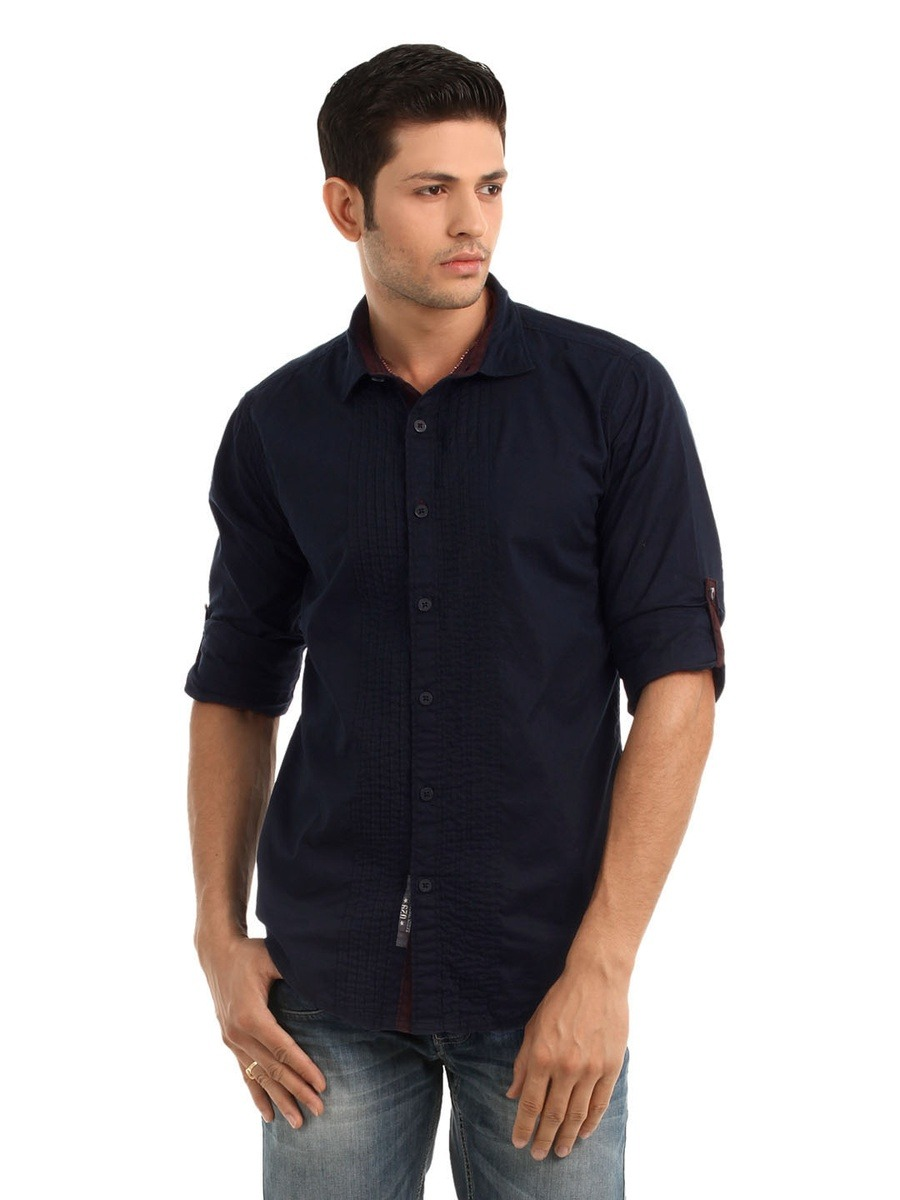

### ✅ verdict: `ok`

{
  "transcripts": {
    "audio": "Hi, selling my navy blue shirt, size large, worn only twice, no stains, pick up downtown or I can ship it."
  },
  "attributes": {
    "articleType": "Shirts",
    "gender": "Men",
    "baseColour": "Navy Blue",
    "season": "Spring",
    "usage": "Casual"
  },
  "timings_s": {
    "asr": 1.164,
    "text_moderation": 0.008,
    "image_moderation": 0.037,
    "attributes": 1.062
  }
}


In [2]:
_ = show(listing_id="shirt", text="Basics Men Navy Shirt, size L",
         photos=[D / "demo/41602.jpg"], audio=D / "demo/voice_shirt.wav")

## 2. Оружие на фото, текст нейтральный

Текст ничего не выдаёт, ловит только CLIP по фото.

**Текст:** Vintage collectible, great condition, pickup only

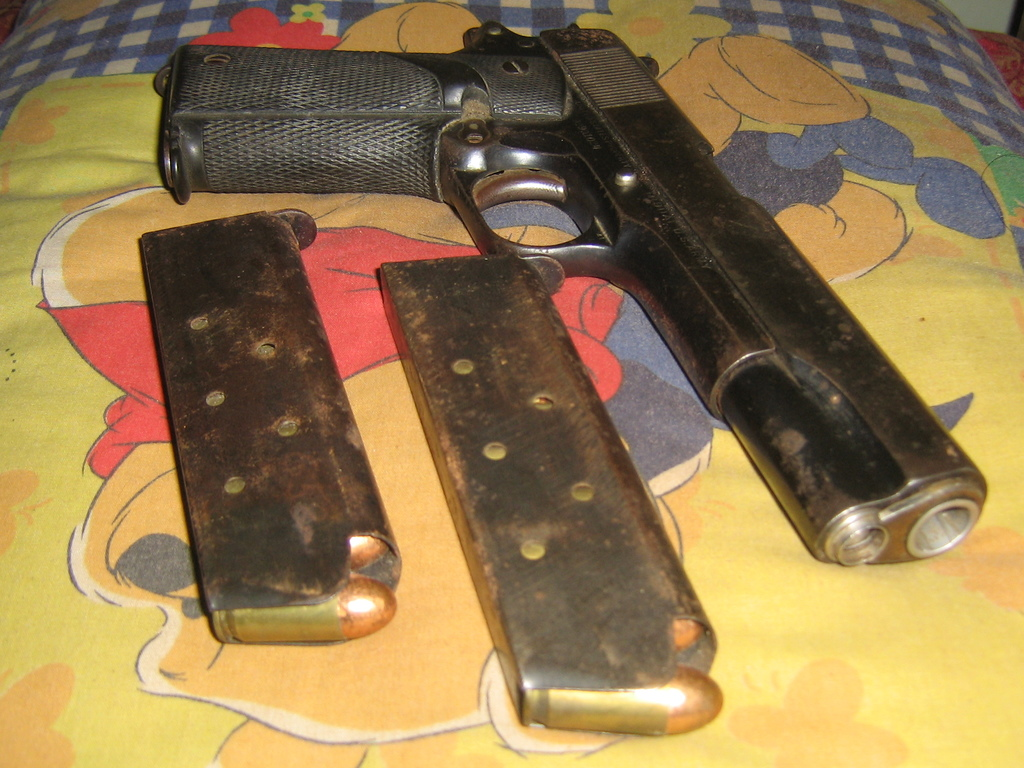

### ⛔ verdict: `not_ok`

{
  "reasons": [
    "photo 1: forbidden item firearms (0.90)"
  ],
  "timings_s": {
    "text_moderation": 0.242,
    "image_moderation": 0.017
  }
}


In [3]:
_ = show(listing_id="handgun", text="Vintage collectible, great condition, pickup only",
         photos=[D / "open_images/forbidden/firearms/0c87545ba250f18c.jpg"])

## 3. Оскорбления в голосовом

Текст и фото чистые, но Whisper расшифровывает голосовое, и toxic-bert находит оскорбление в транскрипте: цепочка ASR → модерация текста.

**Текст:** White sports shoes, size 43

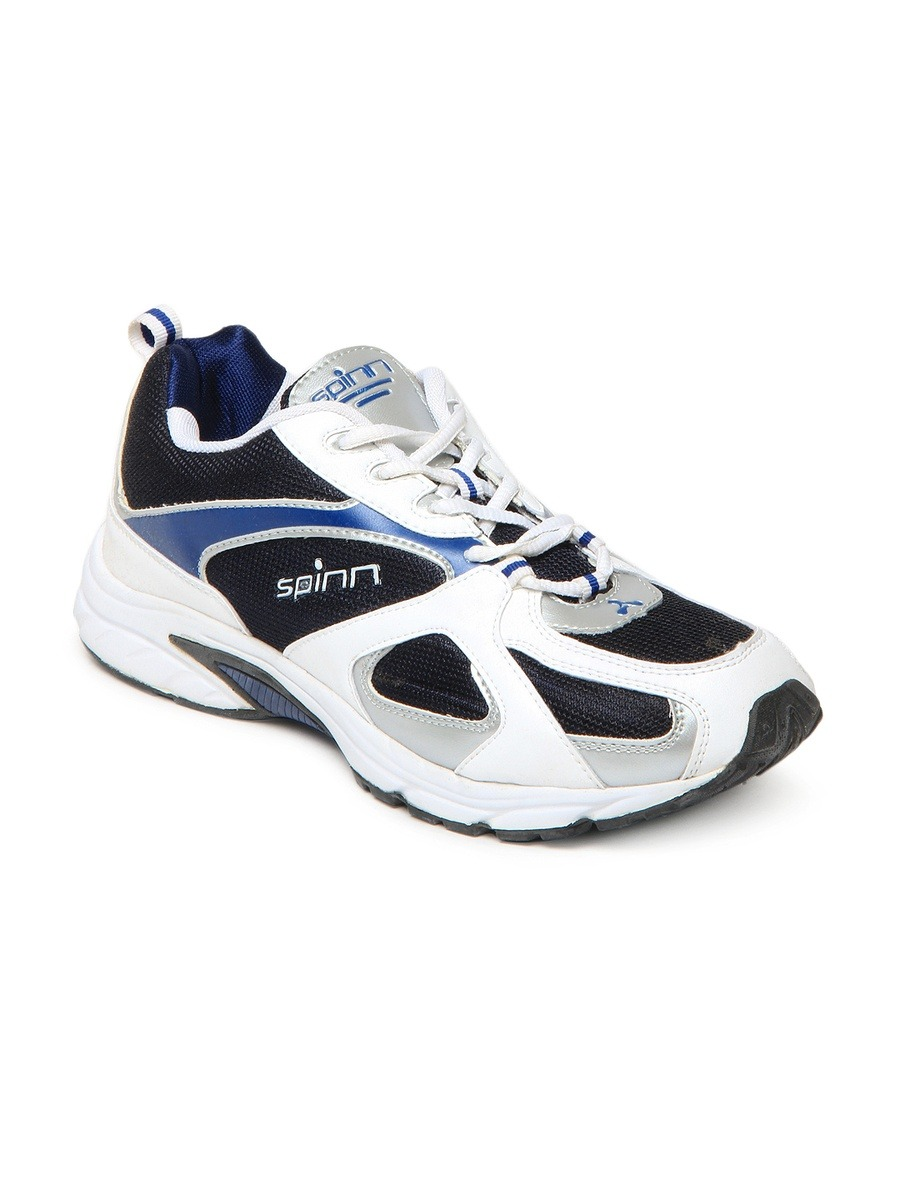

### ⛔ verdict: `not_ok`

{
  "reasons": [
    "audio_transcript: toxic (0.98)"
  ],
  "review": [
    "audio_transcript: insult (0.89)"
  ],
  "transcripts": {
    "audio": "Sneakers are basically new. Price is final, so don't waste my time with stupid offers, you idiots."
  },
  "timings_s": {
    "asr": 0.713,
    "text_moderation": 0.01,
    "image_moderation": 0.013
  }
}


In [4]:
_ = show(listing_id="sneakers", text="White sports shoes, size 43",
         photos=[D / "demo/36426.jpg"], audio=D / "demo/voice_rude.wav")

## 4. Видео с человеком в кадре

Объявление разрешено, но человек на видео размывается. Размытый ролик сохраняется в `results/demo/`.

**Текст:** Women's black top for yoga, like new

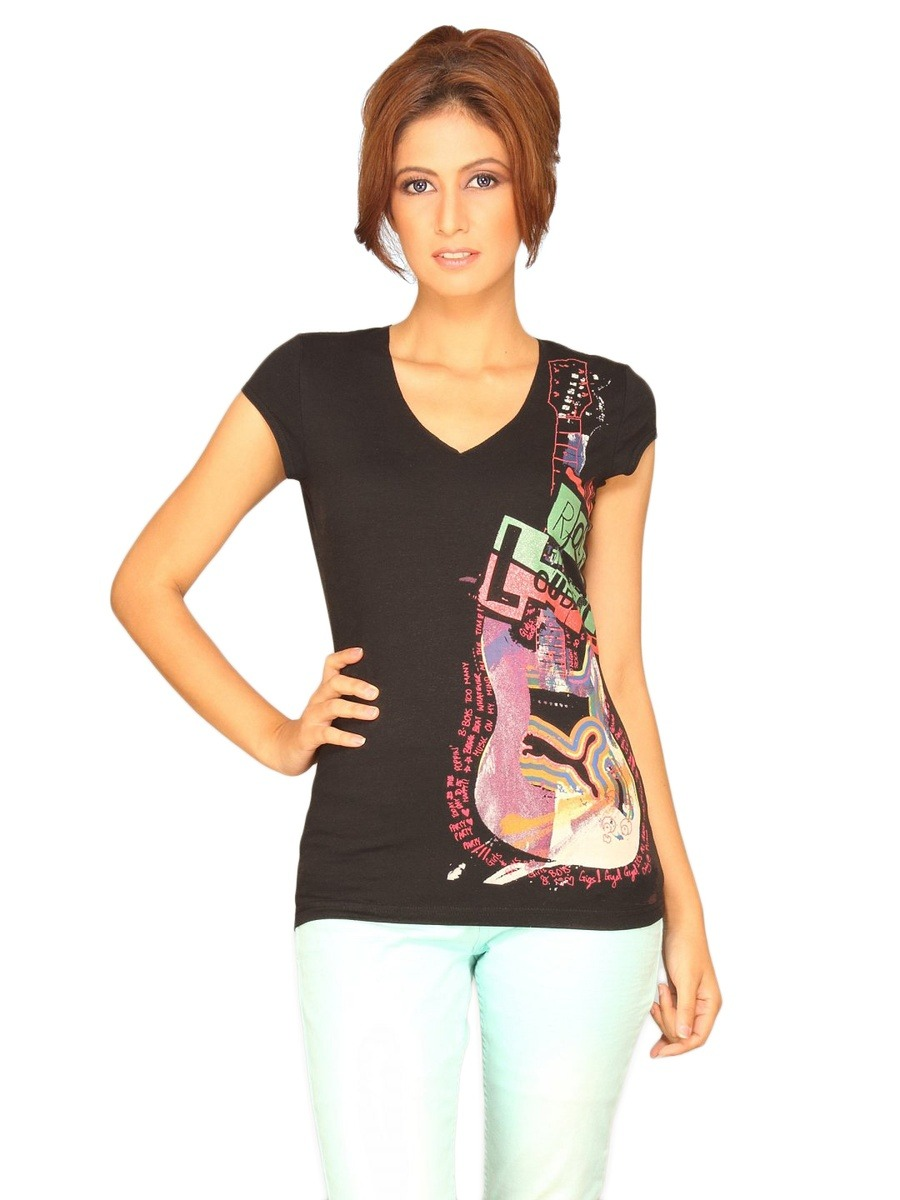

**Видео: кадр до / после размытия**

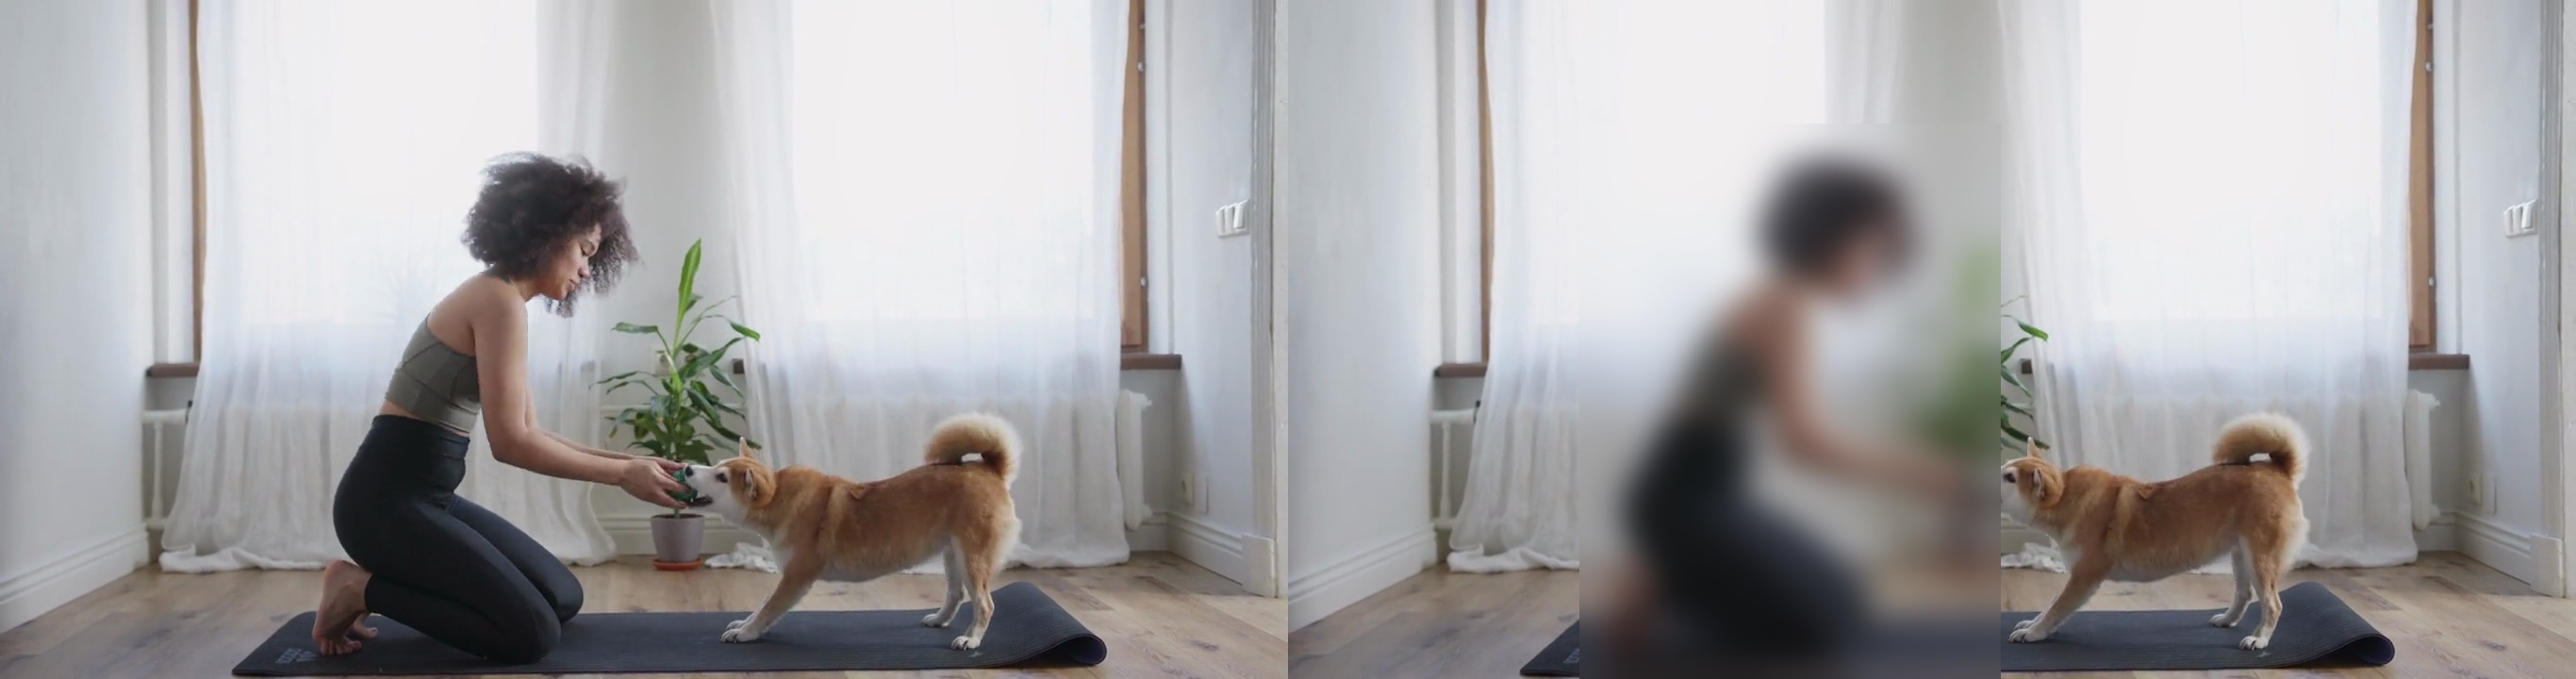

### ✅ verdict: `ok`

{
  "attributes": {
    "articleType": "Tshirts",
    "gender": "Women",
    "baseColour": "Black",
    "season": "Summer",
    "usage": "Casual"
  },
  "timings_s": {
    "text_moderation": 0.009,
    "image_moderation": 0.013,
    "video": 6.042,
    "attributes": 1.947
  }
}


In [5]:
_ = show(listing_id="yoga", text="Women's black top for yoga, like new",
         photos=[D / "demo/5884.jpg"], video=D / "videos/pexels_4057411.mp4")

## Сводка

In [6]:
import pandas as pd

pd.DataFrame([{"id": r["id"], "verdict": r["verdict"], "reasons": "; ".join(r["reasons"] + r["review"]),
               "attributes": ", ".join(r["attributes"].values()) if r.get("attributes") else "",
               "total_s": round(sum(r["timings_s"].values()), 2)} for r in results])

,id,verdict,reasons,attributes,total_s
0,shirt,ok,,"Shirts, Men, Navy Blue, Spring, Casual",2.27
1,handgun,not_ok,photo 1: forbidden item firearms (0.90),,0.26
2,sneakers,not_ok,audio_transcript: toxic (0.98); audio_transcri...,,0.74
3,yoga,ok,,"Tshirts, Women, Black, Summer, Casual",8.01
